## **Context:**

The rapid growth of information has created information overload, making it difficult for consumers to choose products online. Recommender systems address this problem by providing personalized product suggestions that improve user engagement and support businesses. Major e-commerce companies such as Amazon, Walmart, Target, and Etsy invest heavily in recommendation algorithms to enhance the customer experience. Amazon, in particular, uses AI-powered techniques like item-to-item collaborative filtering to analyze customer preferences and deliver accurate, real-time product recommendations at scale

## **Objective:**
As a Data Science Manager at Amazon, your goal is to extract meaningful insights from the data and build system that recommends products to online consumers.

## **Dataset:**
The Amazon dataset will contain the following attributes:

userId: Every user identified with a unique id

productId: Every product identified with a unique id

Rating: The rating of the corresponding product by the corresponding user

timestamp: Time of the rating. We **will not** use this column to solve the current problem

In [4]:
# Import numpy package to our notebook and check which version is installed. For this project we want to be using version 1.26.0
import numpy as np
print(np.__version__)

ModuleNotFoundError: No module named 'numpy'

In [5]:
import numpy as np

ModuleNotFoundError: No module named 'numpy'

In [6]:
import sys
print(sys.executable)

C:\Users\navar\anaconda3\python.exe


In [8]:
import numpy as np
!pip uninstall numpy -y
%pip install numpy==1.26.4

ModuleNotFoundError: No module named 'numpy'

In [1]:
# Install scikit-surprise , an open source (accessible) python library specifically designed for use with recommendation systems
!pip install scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.3 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.3 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12.3 MB 4.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.3 MB 4.5 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.3 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.3 MB 4.9 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.3 MB 5.2 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------- 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.6 which is incompatible.


In [1]:
# Import packages that will be used for analysis
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sb

In [10]:
df = pd.read_csv(r"C:\Users\navar\ratings_Electronics.csv", header=None) 

In [11]:
# Because the dataframe had no column headers/titles, here we name the columns
new_column_names = {0: 'userId', 1: 'productId', 2: 'Rating', 3: 'timestamp'}
df.rename(columns=new_column_names, inplace=True)
display(df.head())

,userId,productId,Rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


## 'Shaping and Trimming' the Data

For this project, we will be disposing of the timestamp column


In [12]:
df = df.drop(columns=['timestamp'])

This dataset is very large and has 7,824,482 observations. Since it is difficult to compute and build a model with all these values and we are also dealing with inconsistent data entries- we will reduce the data and extract only useful entries.

In [13]:
# Increasing the rating count if the user has seen the product previously
ratings_count = dict()

for user in df['userId']:
  if user in ratings_count:
    ratings_count[user] += 1
  else:
    ratings_count[user] = 1

In [14]:
# Users should have rated at least 50 items to be included in the analysis
RATINGS_CUTOFF = 50
remove_users = []

for users, num_ratings in ratings_count.items():
  if num_ratings < RATINGS_CUTOFF:
    remove_users.append(users)

df = df[~df['userId'].isin(remove_users)]

In [15]:
# Increasing the rating count if the product has been rated previously
products = df.productId

ratings_count = dict()

for products in products:
  if products in ratings_count:
    ratings_count[products] += 1
  else:
    ratings_count[products] = 1

In [16]:
# Filtering out products that have been rated less than 5 times to keep our data applicable
RATINGS_CUTOFF = 5

remove_users = []

for user in num_ratings, ratings_count.items():
  if num_ratings < RATINGS_CUTOFF:
    remove_users.append(user)

df = df[~df['productId'].isin(remove_users)]

## 'Travel and Explore' through the data
 Checking the new dataframe values, info, shape, and description

In [17]:
df.head()

,userId,productId,Rating
94,A3BY5KCNQZXV5U,0594451647,5.0
118,AT09WGFUM934H,0594481813,3.0
177,A32HSNCNPRUMTR,0970407998,1.0
178,A17HMM1M7T9PJ1,0970407998,4.0
492,A3CLWR1UUZT6TG,0972683275,5.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125871 entries, 94 to 7824444
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     125871 non-null  object 
 1   productId  125871 non-null  object 
 2   Rating     125871 non-null  float64
dtypes: float64(1), object(2)
memory usage: 3.8+ MB


In [19]:
df.shape

(125871, 3)

In [20]:
#check the data for null values
nulls = df[df.isnull().any(axis=1)]
print(nulls)

Empty DataFrame
Columns: [userId, productId, Rating]
Index: []


In [21]:
df.describe()

,Rating
count,125871.000000
mean,4.261339
std,1.062144
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


*Observations:*


*   The dataframe has no headers
*   We are working with a large dataframe with over 7 million values spread throughout 4 columns
*   There are no present nulls in the dataframe

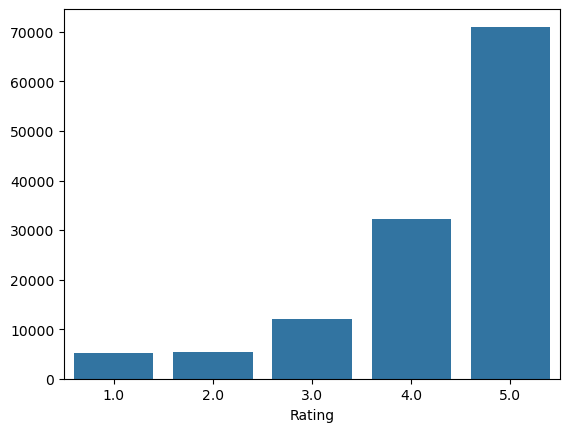

In [23]:
# Visual showing the rating count per rating number
sb.barplot(x=df['Rating'].value_counts().index, y=df['Rating'].value_counts().values)
plt.show()

*Observation:* The rating '5.0' is the most popular rating in our dataset.

In [26]:
# Check unique value count for each column
columns = df.columns
print(columns)

column_name_input = input("enter column name: ")

if column_name_input in columns:
  print (f"The number of unique values in column '{column_name_input}' is: {df[column_name_input].nunique()}")
else:
  print ("Column name is not identifiable")

Index(['userId', 'productId', 'Rating'], dtype='object')


enter column name:  productId


The number of unique values in column 'productId' is: 48190


In [27]:
top_10_users = df['userId'].value_counts().head(10)
print(top_10_users)

userId
A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
Name: count, dtype: int64


In [28]:
# Checking the minimum and maximum count of ratings per user. The rating cutoff is 50 for the minimum value.
min = df['userId'].value_counts().min()
max = df['userId'].value_counts().max()

print("spectrum values of users: ", f"min: {min}, max: {max}")

spectrum values of users:  min: 50, max: 520


*Observation*: In our dataset the minimum ratings count is 50, as maintained from the rating_cutoff function, and our maximum ratings count is 520

## Model 1: 'Rating' Based Recommendation

In [30]:
# aggregating the average rating per poduct
avg_rating = df.groupby('productId')['Rating'].mean()
print("average rating per product is: ", avg_rating.mean())

average rating per product is:  4.214898962451574


In [31]:
# Creating a new dataframe with the average rating per product along with the count of ratings per product
ratings_count = df.groupby('productId')['Rating'].count()
product_stats = pd.DataFrame({
    'AverageRating': avg_rating,
    'RatingCount': ratings_count
})

print(product_stats.head())

print()
print()

sorted_products_by_avg_rating = product_stats.sort_values(by='AverageRating', ascending=False)
display(sorted_products_by_avg_rating.head(5))

            AverageRating  RatingCount
productId                             
0594451647       5.000000            1
0594481813       3.000000            1
0970407998       2.500000            2
0972683275       4.750000            4
1400501466       3.333333            6




,AverageRating,RatingCount
productId,,
1400699169,5.0,1
B00LKG1MC8,5.0,1
0594451647,5.0,1
1685560148,5.0,1
B00LGQ6HL8,5.0,5


In [32]:
# Defining a function to retrieve the top (n) products based on the highest average rating and minimum interactions

def top_n_products(df, n, min_interactions=50):

    recommendations = df[df['RatingCount'] > min_interactions]

    recommendations = recommendations.sort_values(by='AverageRating', ascending=False)

    return recommendations.index[:n]

In [33]:
# Top 5 products, averaged, with min 50 interactions
top_products = top_n_products(product_stats, n=5)
print("Top 5 products by average rating with minimum 50 interactions:")
print(top_products)
print()
top_products_info = product_stats.loc[top_products, ['AverageRating']]

Top 5 products by average rating with minimum 50 interactions:
Index(['B001TH7GUU', 'B003ES5ZUU', 'B0019EHU8G', 'B006W8U2MU', 'B000QUUFRW'], dtype='object', name='productId')



In [34]:
# Top 10 products, averaged, with min 100 interactions
def top_n_products(df, n, min_interactions=100):

    recommendations = df[df['RatingCount'] > min_interactions]

    recommendations = recommendations.sort_values(by='AverageRating', ascending=False)

    return recommendations.index[:n]

top_products = top_n_products(product_stats, n=10)
print("Top 10 products by average rating with minimum 100 interactions:")
print(top_products)

Top 10 products by average rating with minimum 100 interactions:
Index(['B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B002V88HFE', 'B004CLYEDC',
       'B00834SJSK', 'B0034CL2ZI', 'B00834SJNA', 'B00829TIEK', 'B00829THK0'],
      dtype='object', name='productId')


## Model 2: Collaborative Filtering Recommendation System

In [35]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

In [36]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

In [37]:
# Load the data reader, load the data, split the data into training/testing sets
reader = Reader(rating_scale=(0, 5))

data = Dataset.load_from_df(df[['userId', 'productId', 'Rating']], reader)

trainset, testset = train_test_split(data, test_size=0.40, random_state=42)

In [38]:
# Creating the User-User based collaborative filtering model using the K-Nearest neighbors algorithm
from collections import defaultdict
sim_options = {'name': 'cosine',
               'user_based': True}

sim_user_user = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

sim_user_user.fit(trainset)

precision_recall_at_k(sim_user_user)

RMSE: 1.1100
Precision:  0.859
Recall:  0.383
F_1 score:  0.53


In [39]:
# Initializing the model (or as some say, "Takeoff!")
userID_1 = 'A3LDPF5FMB782Z'
productID_1 = '1400501466'
Rating = df['Rating'].value_counts().count()

prediction = sim_user_user.predict(userID_1, productID_1)

# You can access the predicted rating using .est attribute
print(f"Predicted rating for User {userID_1} concerning Product {productID_1} is: {prediction.est}")

Predicted rating for User A3LDPF5FMB782Z concerning Product 1400501466 is: 4.0


In [40]:
def has_interacted(dataframe, user_id_to_check, product_id_to_check):
    # Filter the DataFrame for the specific user and product
    interaction = dataframe[(dataframe['userId'] == user_id_to_check) &
                              (dataframe['productId'] == product_id_to_check)]

    # If an interaction exists, return the rating; otherwise, return None
    if not interaction.empty:
        return f"This User has interacted with the product and given it a rating of: {interaction['Rating'].iloc[0]}"
    else:
        return f"User has not interacted with the product"

In [41]:
has_interacted(df, userID_1, productID_1)

'This User has interacted with the product and given it a rating of: 5.0'

*Observation:* The model predicted User A3LDPF5FMB782Z would rate Product 1400501466 a 4.0 but after checking if the User has already rated the Product, we see the User already interacted with the Product and given it a rating of 5.

In [42]:
productID_to_check = '1400501466'

# Get all unique user IDs that have interacted with the specific productID
interacting_users = df[df['productId'] == productID_to_check]['userId'].unique()

# Get all unique user IDs in the entire dataset
all_users = df['userId'].unique()

# Find user IDs that are in 'all_users' but not in 'interacting_users'
non_interacting_users = [user for user in all_users if user not in interacting_users]

print(f"Users who have NOT interacted with Product {productID_to_check}:")
print(non_interacting_users[:10]) # Displaying the first 10 to keep the output concise
print(f"Total number of users who have NOT interacted: {len(non_interacting_users)}")

Users who have NOT interacted with Product 1400501466:
['A3BY5KCNQZXV5U', 'AT09WGFUM934H', 'A32HSNCNPRUMTR', 'A17HMM1M7T9PJ1', 'A3CLWR1UUZT6TG', 'A3TAS1AG6FMBQW', 'A2Y4H3PXB07WQI', 'A25RTRAPQAJBDJ', 'A18S2VGUH9SCV5', 'A1K4G5YJDJQI6Q']
Total number of users who have NOT interacted: 1534


In [43]:
userID_2 = 'A3BY5KCNQZXV5U'
productID_1 = '1400501466'
Rating = df['Rating'].value_counts().count()

prediction = sim_user_user.predict(userID_2, productID_1)

print(f"Predicted rating for User {userID_2} concerning Product {productID_1} is: {prediction.est}")

Predicted rating for User A3BY5KCNQZXV5U concerning Product 1400501466 is: 4.265339900956013


In [44]:
has_interacted(df, userID_2, productID_1)

'User has not interacted with the product'

## Tuning the hyperparamters of the user-item similarity recommendation system


In [45]:
# Hyperparameter tuning for the user-user similarity based model
param_grid = {'k': [40], 'min_k': [1],
              'sim_options': {'name': ['cosine'],
                              'user_based': [True], 'min_support':[4]}
              }

gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

gs.fit(data)

print(gs.best_score['rmse'])

print(gs.best_params['rmse'])

1.0778395220611536
{'k': 40, 'min_k': 1, 'sim_options': {'name': 'cosine', 'user_based': True, 'min_support': 4}}


In [46]:
# Retrieve the best parameters from GridSearchCV
best_params = gs.best_params['rmse']

# Extract k and sim_options from the best parameters
best_k = best_params['k']
best_sim_options = best_params['sim_options']

# Initialize KNNBasic with the optimal parameters
sim_user_user_tuned = KNNBasic(k=best_k, sim_options=best_sim_options, verbose=False, random_state=1)

# Train the model on the training data
sim_user_user_tuned.fit(trainset)

# Evaluate the tuned model
precision_recall_at_k(sim_user_user_tuned)

RMSE: 1.0807
Precision:  0.824
Recall:  0.367
F_1 score:  0.508


In [47]:
# Computing our model with k=10
sim_user_user_tuned = KNNBasic(k=10, sim_options=best_sim_options, verbose=False, random_state=1)

sim_user_user_tuned.fit(trainset)

precision_recall_at_k(sim_user_user_tuned)

RMSE: 1.0807
Precision:  0.824
Recall:  0.367
F_1 score:  0.508


*Observation:* Our model works identically with k = 10 or 40

In [48]:
# Predict the rating for a specific user and product using the tuned model
prediction1 = sim_user_user_tuned.predict(userID_1, productID_1)
prediction2 = sim_user_user_tuned.predict(userID_2, productID_1)

print(f"Predicted rating for User {userID_1} concerning Product {productID_1} is: {prediction1.est}")
print(f"Predicted rating for User {userID_2} concerning Product {productID_1} is: {prediction2.est}")


Predicted rating for User A3LDPF5FMB782Z concerning Product 1400501466 is: 5
Predicted rating for User A3BY5KCNQZXV5U concerning Product 1400501466 is: 4.265339900956013


*Observation*: After hypertuning our model, the prediction for user_1s rating of product_1 is accurate. 

## Implementing the recommendation algorithm based on optimized KNNBasic model

In [50]:
def get_recommendations(data, userId, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'userId', columns = 'productId', values = 'Rating')

    # Extracting those product ids which the userId has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[userId][user_item_interactions_matrix.loc[userId].isnull()].index.tolist()

    # Looping through each of the product ids which userId has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(userId, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

In [51]:
df_recs = get_recommendations(df, 'A3LDPF5FMB782Z', 5, sim_user_user_tuned)
print(df_recs)

[('0594451647', np.float64(4.265339900956013)), ('0594481813', np.float64(4.265339900956013)), ('0970407998', np.float64(4.265339900956013)), ('0972683275', np.float64(4.265339900956013)), ('1400532620', np.float64(4.265339900956013))]


*Observation*: Our model has recommended products that are all rated similarly. 

## Item-Item Similarity-based Collaborative Filtering Recommendation System


In [53]:
# Creating the User-User based collaborative filtering model using the K-Nearest neighbors algorithm
sim_options = {'name': 'cosine',
               'user_based': False}

sim_item_item = KNNBasic(sim_options=sim_options, verbose=False, random_state=1)

sim_item_item.fit(trainset)

precision_recall_at_k(sim_item_item)

RMSE: 1.1105
Precision:  0.827
Recall:  0.369
F_1 score:  0.51


In [54]:
# Predict the rating for a specific user and product using the tuned model
prediction1 = sim_item_item.predict(userID_1, productID_1)
prediction2 = sim_item_item.predict(userID_2, productID_1)

print(f"Predicted rating for User {userID_1} concerning Product {productID_1} is: {prediction1.est}")
print(f"Predicted rating for User {userID_2} concerning Product {productID_1} is: {prediction2.est}")


Predicted rating for User A3LDPF5FMB782Z concerning Product 1400501466 is: 4.25
Predicted rating for User A3BY5KCNQZXV5U concerning Product 1400501466 is: 4.265339900956013


## Hyperparameter tuning the item-item similarity-based model


In [55]:
# Hyperparameter tuning for the item-item similarity based model
param_grid = {'k': [10,20,30], 'min_k': [3,6,9],
              'sim_options': {'name': ['msd','cosine'],
                              'user_based': [False], 'min_support':[4]}
              }

gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

gs.fit(data)

print(gs.best_score['rmse'])

print(gs.best_params['rmse'])

MemoryError: Unable to allocate 10.2 GiB for an array with shape (37003, 37003) and data type float64

In [ ]:
# Retrieve the best parameters from GridSearchCV
best_params = gs.best_params['rmse']

# Extract k and sim_options from the best parameters
best_k = best_params['k']
best_sim_options = best_params['sim_options']

# Initialize KNNBasic with the optimal parameters
sim_item_item_tuned = KNNBasic(k=best_k, sim_options=best_sim_options, verbose=False, random_state=1)

# Train the model on the training data
sim_item_item_tuned.fit(trainset)

# Evaluate the tuned model
precision_recall_at_k(sim_item_item_tuned)

In [ ]:
# Predict the rating for a specific user and product using the tuned model
prediction1 = sim_user_user_tuned.predict(userID_1, productID_1)
prediction2 = sim_user_user_tuned.predict(userID_2, productID_1)

print(f"Predicted rating for User {userID_1} concerning Product {productID_1} is: {prediction1.est}")
print(f"Predicted rating for User {userID_2} concerning Product {productID_1} is: {prediction2.est}")